# 원본 노트북 링크:
- https://github.com/chaeyoung-lee/math-formula-recognition?tab=readme-ov-file

In [1]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

os.chdir('/content/drive/MyDrive/Colab Notebooks/프로젝트/2025 한양대 졸업프로젝트 HMER/OMRiDA 2')

# Utils

- 필요에 따라 추후 WER도 계산하는거 구현해서 metric으로 사용해도 좋을듯

In [3]:
import matplotlib.pyplot as plt

def plot_dataset(images, labels, grid_width, grid_height, figure_width, figure_height, y_hats=None, vocab=None, wspace=0.5, hspace=1):

  # images, labels는 torch.tensor 타입으로 들어온다고 가정

  f, ax = plt.subplots(grid_height, grid_width, squeeze=False)
  f.set_size_inches(figure_width, figure_height)
  img_idx = 0

  eos_idx = 1

  for i in range(0, grid_height):
    for j in range(0, grid_width):
      image = images[img_idx].cpu().detach()
      label = labels[img_idx].cpu().detach()
      title_color = 'k'

      assert vocab is not None, "vocab을 입력하세요"

      label = label.tolist()
      label = label[1:label.index(eos_idx)]     # <sos>, <eos> 부분 제외 (EOS_IDX == 2) - <eos> 이전까지 뽑아서 <eos>이후 <pad> 부분도 제외되도록
      label = vocab.decode(label)               # list -> str

      if y_hats is not None:
            y_hat = y_hats[img_idx].cpu().detach().tolist()

            if eos_idx in y_hat:
                y_hat = y_hat[:y_hat.index(eos_idx)]   # <eos> 존재하면 <eos> 이후부분 (<eos> 및 <pad>) 무시

            y_hat = vocab.decode(y_hat)         # list -> str


            if label != y_hat:
                title_color = 'r'

            label = f'gt: {label}\npred:{y_hat}'

      ax[i][j].axis('off')
      ax[i][j].set_title(label, color=title_color)
      ax[i][j].imshow(image.permute(1,2,0).numpy(), aspect='auto', cmap='gray')
      img_idx += 1

    plt.subplots_adjust(left=0, bottom=0, right=2, top=2, wspace=wspace, hspace=hspace)
  plt.show()

In [4]:
import editdistance

def exprate_k(preds, targets, k=0, eos_idx=1):

    # preds, targets에는 <sos>가 제거된 채로 함수인자로 들어온다고 가정

    # preds: (B, T-1)
    # targets: (B, T-1)

    assert preds.shape[0] == targets.shape[0], "예측 label과 정답 label의 배치 크기가 다릅니다"

    cnt = 0
    for pred_seq, tgt_seq in zip(preds, targets):

        pred = pred_seq.tolist()
        tgt = tgt_seq.tolist()

        if eos_idx in pred:
            pred = pred[:pred.index(eos_idx)]

        if eos_idx in tgt:
            tgt = tgt[:tgt.index(eos_idx)]

        diff = editdistance.eval(pred, tgt)

        if diff<=k:
            cnt += 1

    return cnt / preds.shape[0]


def WER(preds, targets, eos_idx=1):

    # preds, targets에는 <sos>가 제거된 채로 함수인자로 들어온다고 가정

    # preds: (B, T-1)
    # targets: (B, T-1)

    assert preds.shape[0] == targets.shape[0], "예측 label과 정답 label의 배치 크기가 다릅니다"

    sum_wer = 0.0
    for pred_seq, tgt_seq in zip(preds, targets):

        pred = pred_seq.tolist()
        tgt = tgt_seq.tolist()

        if eos_idx in pred:
            pred = pred[:pred.index(eos_idx)]

        if eos_idx in tgt:
            tgt = tgt[:tgt.index(eos_idx)]

        distance = editdistance.eval(pred, tgt)
        length = len(tgt)

        sum_wer += (distance/length)

    return sum_wer / preds.shape[0]

In [5]:
import os
import json
from pathlib import Path

def save_log(log_dict, save_path="log.json"):

    Path(save_path).parent.mkdir(parents=True, exist_ok=True)
    with open(save_path, "w", encoding="utf-8") as f:
        json.dump(log_dict, f, indent=2)
    print(f"저장 완료: {save_path}")


def plot_loss_curve(log_dict, metric="loss", overlap=False):

    assert metric in ["loss", "expr@0", "expr@1", "expr@2", "expr@3", "wer"], "metric은 loss, expr@0, expr@2, expr@3, wer 중 선택하여 입력해야합니다"

    if overlap==False:
        fig, axes = plt.subplots(2,1)

        fig.suptitle(f"{metric} Curve")

        # train
        train = log_dict["Train"]
        epochs = range(1, len(train)+1)

        train_metric = []
        for log in train:
            train_metric.append(log[metric])

        axes[0].plot(epochs, train_metric, marker='o')
        axes[0].set_xlabel("Epoch")
        axes[0].set_ylabel(f"train {metric}")
        axes[0].grid(True)


        # valid
        valid = log_dict["Valid"]
        epochs = range(1, len(valid)+1)

        valid_metric = []
        for log in valid:
            valid_metric.append(log[metric])

        axes[1].plot(epochs, valid_metric, marker='o')
        axes[1].set_xlabel("Epoch")
        axes[1].set_ylabel(f"valid {metric}")
        axes[1].grid(True)

        plt.tight_layout()
        plt.show()

    else:

        # train
        train = log_dict["Train"]
        epochs = range(1, len(train)+1)

        train_metric = []
        for log in train:
            train_metric.append(log[metric])

        plt.plot(epochs, train_metric, marker='o', label=f"Train {metric}")


        # valid
        valid = log_dict["Valid"]
        epochs = range(1, len(valid)+1)

        valid_metric = []
        for log in valid:
            valid_metric.append(log[metric])

        plt.plot(epochs, valid_metric, marker='o', label=f"Valid {metric}")

        plt.xlabel("Epoch")
        plt.ylabel(f"{metric}")
        plt.title(f"{metric} Curve")

        plt.legend()
        plt.grid(True)
        plt.show()

In [6]:
import gspread

def save_test_result(experiment_name, val_dict):
    """ 실험결과를 구글스프레드시트에 저장 """

    gc = gspread.service_account(filename="service_account.json")
    sh = gc.open("test_results")

    # experiment_name이 스프레드시트의 각 sheet (윈도우)에 존재하는지 확인
    for metric in ["loss", "expr@0", "expr@1", "expr@2", "expr@3", "wer"]:
        worksheet = sh.worksheet(metric)

        try:
            row = worksheet.find(experiment_name).row

            # 이미 해당 실험이 과거에 진행된 경우가 있어 값들이 채워져있다면, 새로 실험하는 것이므로 해당 실험의 이전값들을 모든 sheet (윈도우)에 대해서 초기화해주고 시작
            range = f"B{row}:I{row}"
            val = [[""] * 8]
            worksheet.batch_update([{
                "range": range,
                "values": val
            }])

        except:
            last_row = len(worksheet.col_values(1))  # A열 중 값이 채워진 부분의 마지막 행번호
            worksheet.update_cell(last_row+1, 1, experiment_name)

    for metric in val_dict.keys():
        worksheet = sh.worksheet(metric)
        row = worksheet.find(experiment_name).row

        range = f"B{row}:I{row}"
        worksheet.batch_update([{
            "range": range,
            "values": [val_dict[metric]]
        }])

# Config (Global Parameters)
- 변경사항: optimizer 옵션을 config에 추가, weight_decay 적용

In [7]:
import torch
DEVICE = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"

In [8]:
DEVICE

'cuda'

In [9]:
import os, json
import torch

CFG = {
  "img_size": (128,768),
  "pad_idx": 112,
  "eos_idx": 1,

  "data": {
    "crohme": {
      "hme_img": "data/preprocessed/train/paired/crohme/hme_preprocessed",
      "pme_img": "data/preprocessed/train/paired/crohme/pme_preprocessed",
      "caption": "data/preprocessed/train/paired/crohme/caption.txt",
    },
    "im2latex": {
      "hme_img": "data/preprocessed/train/paired/im2latex/hme_img_train",
      "pme_img": "data/preprocessed/train/paired/im2latex/pme_img_train",
      "caption": "data/preprocessed/train/paired/im2latex/caption_train.txt",
    },
  },

  "model": {
    "vocab_size": 112,
    "encoder_emb_dim": 256,
    "decoder_emb_dim": 256,
    "decoder_hidden_dim": 512
  },

  "training": {
    "batch_size": 4,
    "epochs": 100,
    "learning_rate": 1e-3,   # 사실상 CosineAnnealingWarmupRestarts사용하면 이 부분의 학습률은 적용 안되는 셈임
    "match_weight": 0.2,      # DWAP에는 사용되지 않는 파라미터
    "optimizer": "adadelta",
    "weight_decay": 1e-4,
    "grad_clip": 1.0,
    "tf_ratio": 0.5
  },

  "testing": {"max_len": 150}
}

num_steps_in_epoch = (8834*0.8)//CFG["training"]["batch_size"]
epochs = CFG["training"]["epochs"]

scheduler_info = {"name": "StepLR"}

# params_cosineAnnealingWarmupRestarts = {"first_cycle_steps": num_steps_in_epoch * epochs,  # 전체 에포크가 한 사이클
#                                         "cycle_mult": 1.0,
#                                         "max_lr": 0.1,
#                                         "min_lr": 5e-4,
#                                         "warmup_steps": num_steps_in_epoch * 0.1 * epochs,  # 전체 에포크의 10%를 warmup에 사용
#                                         "gamma": 1.0
#                                         }
# scheduler_info["params"] = params_cosineAnnealingWarmupRestarts

params_StepLR = {"lr_factor": 0.1,
                 "lr_epochs": 20}

scheduler_info["params"] = params_StepLR

CFG["training"]["early_stop_patience"] = max(4, int(epochs*0.04))


experiment_name = f"(github) DWAP_epoch{epochs}_bs{CFG['training']['batch_size']}_scheduler_StepLR_patience_{CFG['training']['early_stop_patience']}"

CFG["experiment_name"] = experiment_name

paths = {}
paths["best_ckpt"] = f"runs/{experiment_name}/best_model.pth"
paths["last_ckpt"] = f"runs/{experiment_name}/last_model.pth"
paths["train_log_json"] = f"runs/{experiment_name}/train_log.json"
paths["CFG"] = f"runs/{experiment_name}/config.json"

CFG["paths"] = paths

CFG["scheduler"] = scheduler_info

In [10]:
# 실험환경 디테일 config 저장

save_log(CFG, CFG["paths"]["CFG"])

저장 완료: runs/(github) DWAP_epoch100_bs4_scheduler_StepLR_patience_4/config.json


In [11]:
# 실험환경 폴더 생성

Path(os.path.join("runs", CFG["experiment_name"])).mkdir(parents=True, exist_ok=True)

# Custom Dataset

## Vocab

In [12]:
# IM2LATEX 캡션 전처리용
def tokenize_formula(formula):
    ans = []
    tokens = formula.strip().split()

    for tok in tokens:
        chk = 0
        for sym in ["cm", "mm", "pt", "in", "ex", "em"]:
            if (tok[-2:] == sym) and tok[-3].isdigit():
                num, _ = tok.split(sym)
                num = ' '.join(num).split()
                ans.extend(num)
                ans.append(sym)
                chk = 1
                break

        if chk == 0:
            ans.append(tok)
    return ans


from typing import List

class Vocab:
  SOS_TOKEN = "<sos>"
  EOS_TOKEN = "<eos>"

  def __init__(self):
    self.default_tokens = [self.SOS_TOKEN, self.EOS_TOKEN]
    self.token2idx = {tok: idx for idx, tok in enumerate(self.default_tokens)}
    self.idx2token = self.default_tokens.copy()

  def __len__(self):
    return len(self.idx2token)

  def load_from_txt(self, path):
    with open(path, "r", encoding="latin1") as f:
      for line in f:
        token = line.strip()
        if token not in self.token2idx:
          idx = len(self.token2idx)
          self.token2idx[token] = idx
          self.idx2token.append(token)

  def encode(self, caption: str) -> List[int]:
    tokens = tokenize_formula(caption)
    return [self.token2idx[self.SOS_TOKEN]] + \
           [self.token2idx[token] for token in tokens] + \
           [self.token2idx[self.EOS_TOKEN]]

  def decode(self, token_ids: List[int]) -> str:
    return ' '.join([self.idx2token[token_id] for token_id in token_ids])

vocab = Vocab()
vocab.load_from_txt("vocab.txt")

In [13]:
from torchvision import transforms
import torch
from PIL import ImageOps

def formula_collate_fn(batch):
    images = torch.stack([item["image"] for item in batch], dim=0)
    formulas = torch.nn.utils.rnn.pad_sequence(
        [item["formula"] for item in batch],
        batch_first=True,
        padding_value=CFG["pad_idx"]
    )
    return {"image": images, "formula": formulas}

In [14]:
from pathlib import Path
from torch.utils.data import Dataset
from PIL import Image
import torch


transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize(CFG["img_size"]),
    transforms.Normalize(mean=[0.5], std=[0.5]),]
)


class FormulaDataset(Dataset):
  def __init__(self, img_path, labels_path, transform, vocab):
    self.img_path = img_path
    self.labels_path = labels_path
    self.transform = transform
    self.vocab = vocab

    self.samples = []
    with open(labels_path, "r", encoding="utf-8") as f:
      for line in f:
        parts = line.strip().split('\t')
        if len(parts)!=2:
          continue
        file_id, caption = parts

        if '.' not in file_id:
          file_id = f"{file_id}.png"

        img_path = os.path.join(self.img_path, file_id)
        if os.path.exists(img_path):
          self.samples.append((img_path, caption))

  def __len__(self):
    return len(self.samples)

  def __getitem__(self, idx):
    img_path, caption = self.samples[idx]
    img = Image.open(img_path).convert('L')

    if self.transform:
      img = self.transform(img)

    caption_tokens = self.vocab.encode(caption)
    caption = torch.tensor(caption_tokens)

    return {"image": img, "formula": caption}

In [15]:
train_path = CFG["data"]["crohme"]["hme_img"]
train_labels_path = CFG["data"]["crohme"]["caption"]

years = [2014, 2016, 2019]
crohme_test_paths = [f"data/preprocessed/test/hme/crohme/{year}/hme_img_preprocessed" for year in years]
crohme_test_labels_paths = [f"data/preprocessed/test/hme/crohme/{year}/caption.txt" for year in years]

cropme_test_paths = [f"data/preprocessed/test/pme/crohme/{year}/pme_img" for year in years]
cropme_test_labels_paths = [f"data/preprocessed/test/pme/crohme/{year}/caption.txt" for year in years]

im2latex_pme_path = "data/preprocessed/test/pme/im2latex/pme_img_test"
im2latex_pme_labels_path = "data/preprocessed/test/pme/im2latex/caption_test.txt"

im2latex_hme_path = "data/preprocessed/test/hme/im2latex/hme_img_test"
im2latex_hme_labels_path = "data/preprocessed/test/hme/im2latex/caption_test.txt"

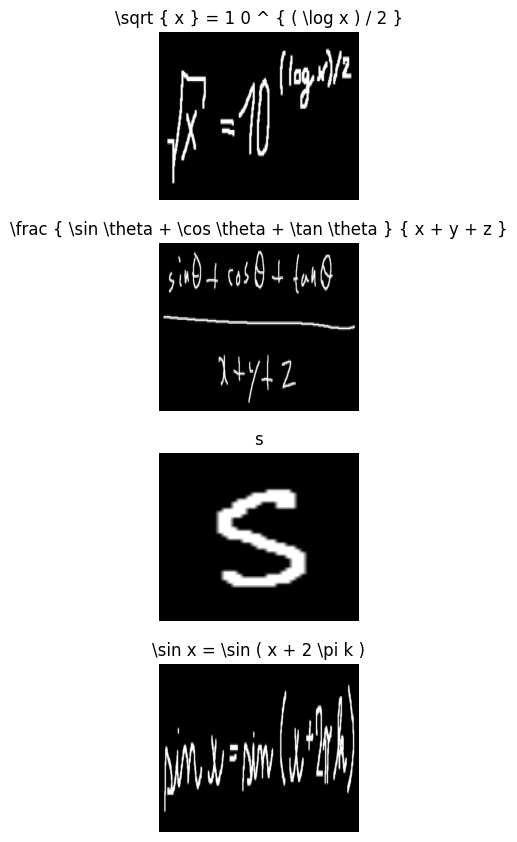

In [16]:
batch_size = CFG["training"]["batch_size"]


# train valid split
trainset = FormulaDataset(train_path, train_labels_path, transform, vocab)
train_size = int(0.8 * len(trainset))
valid_size = len(trainset) - train_size
trainset, validset = torch.utils.data.random_split(trainset,[train_size, valid_size])


# loader

# train, valid
trainloader = torch.utils.data.DataLoader(
    trainset, batch_size=batch_size, shuffle=True, collate_fn=formula_collate_fn
)
validloader = torch.utils.data.DataLoader(
    validset, batch_size=1, shuffle=False, collate_fn=formula_collate_fn
)

# test - CROHME
crohme_testset_2014 = FormulaDataset(crohme_test_paths[0], crohme_test_labels_paths[0], transform, vocab)
crohme_testset_2016 = FormulaDataset(crohme_test_paths[1], crohme_test_labels_paths[1], transform, vocab)
crohme_testset_2019 = FormulaDataset(crohme_test_paths[2], crohme_test_labels_paths[2], transform, vocab)

crohme_testloader_2014 = torch.utils.data.DataLoader(
    crohme_testset_2014, batch_size=1, shuffle=False, collate_fn=formula_collate_fn,
    num_workers=2, pin_memory=True, persistent_workers=True, prefetch_factor=2
)

crohme_testloader_2016 = torch.utils.data.DataLoader(
    crohme_testset_2016, batch_size=1, shuffle=False, collate_fn=formula_collate_fn,
    num_workers=2, pin_memory=True, persistent_workers=True, prefetch_factor=2
)

crohme_testloader_2019 = torch.utils.data.DataLoader(
    crohme_testset_2019, batch_size=1, shuffle=False, collate_fn=formula_collate_fn,
    num_workers=2, pin_memory=True, persistent_workers=True, prefetch_factor=2
)

# test - CROPME
cropme_testset_2014 = FormulaDataset(cropme_test_paths[0], cropme_test_labels_paths[0], transform, vocab)
cropme_testset_2016 = FormulaDataset(cropme_test_paths[1], cropme_test_labels_paths[1], transform, vocab)
cropme_testset_2019 = FormulaDataset(cropme_test_paths[2], cropme_test_labels_paths[2], transform, vocab)

cropme_testloader_2014 = torch.utils.data.DataLoader(
    cropme_testset_2014, batch_size=1, shuffle=False, collate_fn=formula_collate_fn,
    num_workers=2, pin_memory=True, persistent_workers=True, prefetch_factor=2
)

cropme_testloader_2016 = torch.utils.data.DataLoader(
    cropme_testset_2016, batch_size=1, shuffle=False, collate_fn=formula_collate_fn,
    num_workers=2, pin_memory=True, persistent_workers=True, prefetch_factor=2
)

cropme_testloader_2019 = torch.utils.data.DataLoader(
    cropme_testset_2019, batch_size=1, shuffle=False, collate_fn=formula_collate_fn,
    num_workers=2, pin_memory=True, persistent_workers=True, prefetch_factor=2
)


# test - IM2LATEX (vocab 통일한 IM2LATEX의 caption 중 7:3으로 훈련 테스트 데이터 나누어 별도로 저장하여 구성하였음)

im2latex_hme_testset = FormulaDataset(im2latex_hme_path, im2latex_hme_labels_path, transform, vocab)
im2latex_hme_testloader = torch.utils.data.DataLoader(
    im2latex_hme_testset, batch_size=1, shuffle=False, collate_fn=formula_collate_fn,
    num_workers=2, pin_memory=True, persistent_workers=True, prefetch_factor=2
)

im2latex_pme_testset = FormulaDataset(im2latex_pme_path, im2latex_pme_labels_path, transform, vocab)
im2latex_pme_testloader = torch.utils.data.DataLoader(
    im2latex_pme_testset, batch_size=1, shuffle=False, collate_fn=formula_collate_fn,
    num_workers=2, pin_memory=True, persistent_workers=True, prefetch_factor=2
)


# 데이터 확인

batch = next(iter(trainloader))
images = batch['image']
labels = batch['formula']
plot_dataset(images, labels, grid_width=1, grid_height=4, figure_width=1, figure_height=4, vocab=vocab, wspace=0.25, hspace=0.25)

# MODEL

## Encoder

In [17]:
import torch
import torch.nn as nn

# Number of bottlenecks
num_bn = 3
# The depth is half of the actual values in the paper because bottleneck blocks
# are used which contain two convlutional layers
depth = 16
multi_block_depth = depth // 2
growth_rate = 24

n = 256
n_prime = 512
decoder_conv_filters = 256
gru_hidden_size = 256
embedding_dim = 256

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


class BottleneckBlock(nn.Module):
    """
    Dense Bottleneck Block

    It contains two convolutional layers, a 1x1 and a 3x3.
    """

    def __init__(self, input_size, growth_rate, dropout_rate=0.2):
        """
        Args:
            input_size (int): Number of channels of the input
            growth_rate (int): Number of new features being added. That is the ouput
                size of the last convolutional layer.
            dropout_rate (float, optional): Probability of dropout [Default: 0.2]
        """
        super(BottleneckBlock, self).__init__()
        inter_size = num_bn * growth_rate
        self.norm1 = nn.BatchNorm2d(input_size)
        self.relu = nn.ReLU(inplace=True)
        self.conv1 = nn.Conv2d(
            input_size, inter_size, kernel_size=1, stride=1, bias=False
        )
        self.norm2 = nn.BatchNorm2d(inter_size)
        self.conv2 = nn.Conv2d(
            inter_size, growth_rate, kernel_size=3, stride=1, padding=1, bias=False
        )
        self.dropout = nn.Dropout(dropout_rate)

    def forward(self, x):
        out = self.conv1(self.relu(self.norm1(x)))
        out = self.conv2(self.relu(self.norm2(out)))
        out = self.dropout(out)
        return torch.cat([x, out], 1)


class TransitionBlock(nn.Module):
    """
    Transition Block

    A transition layer reduces the number of feature maps in-between two bottleneck
    blocks.
    """

    def __init__(self, input_size, output_size):
        """
        Args:
            input_size (int): Number of channels of the input
            output_size (int): Number of channels of the output
        """
        super(TransitionBlock, self).__init__()
        self.norm = nn.BatchNorm2d(input_size)
        self.relu = nn.ReLU(inplace=True)
        self.conv = nn.Conv2d(
            input_size, output_size, kernel_size=1, stride=1, bias=False
        )
        self.pool = nn.AvgPool2d(kernel_size=2, stride=2)

    def forward(self, x):
        out = self.conv(self.relu(self.norm(x)))
        return self.pool(out)

class DenseBlock(nn.Module):
    """
    Dense block

    A dense block stacks several bottleneck blocks.
    """

    def __init__(self, input_size, growth_rate, depth, dropout_rate=0.2):
        """
        Args:
            input_size (int): Number of channels of the input
            growth_rate (int): Number of new features being added per bottleneck block
            depth (int): Number of bottleneck blocks
            dropout_rate (float, optional): Probability of dropout [Default: 0.2]
        """
        super(DenseBlock, self).__init__()
        layers = [
            BottleneckBlock(
                input_size + i * growth_rate, growth_rate, dropout_rate=dropout_rate
            )
            for i in range(depth)
        ]
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)


class Encoder(nn.Module):
    """Multi-scale Dense Encoder

    A multi-scale dense encoder with two branches. The first branch produces
    low-resolution annotations, as a regular dense encoder would, and the second branch
    produces high-resolution annotations.
    """

    def __init__(
        self, img_channels=1, num_in_features=48, dropout_rate=0.2, checkpoint=None
    ):
        """
        Args:
            img_channels (int, optional): Number of channels of the images [Default: 1]
            num_in_features (int, optional): Number of channels that are created from
                the input to feed to the first dense block [Default: 48]
            dropout_rate (float, optional): Probability of dropout [Default: 0.2]
            checkpoint (dict, optional): State dictionary to be loaded
        """
        super(Encoder, self).__init__()
        self.conv0 = nn.Conv2d(
            img_channels,
            num_in_features,
            kernel_size=7,
            stride=2,
            padding=3,
            bias=False,
        )
        self.norm0 = nn.BatchNorm2d(num_in_features)
        self.relu = nn.ReLU(inplace=True)
        self.max_pool = nn.MaxPool2d(kernel_size=2, stride=2)
        num_features = num_in_features
        self.block1 = DenseBlock(
            num_features,
            growth_rate=growth_rate,
            depth=depth,
            dropout_rate=dropout_rate,
        )
        num_features = num_features + depth * growth_rate
        self.trans1 = TransitionBlock(num_features, num_features // 2)
        num_features = num_features // 2
        self.block2 = DenseBlock(
            num_features,
            growth_rate=growth_rate,
            depth=depth,
            dropout_rate=dropout_rate,
        )

        num_features = num_features + depth * growth_rate
        self.trans2_norm = nn.BatchNorm2d(num_features)
        self.trans2_relu = nn.ReLU(inplace=True)
        self.trans2_conv = nn.Conv2d(
            num_features, num_features // 2, kernel_size=1, stride=1, bias=False
        )
        self.trans2_pool = nn.AvgPool2d(kernel_size=2, stride=2)
        self.multi_block = DenseBlock(
            num_features,
            growth_rate=growth_rate,
            depth=multi_block_depth,
            dropout_rate=dropout_rate,
        )
        num_features = num_features // 2
        self.block3 = DenseBlock(
            num_features,
            growth_rate=growth_rate,
            depth=depth,
            dropout_rate=dropout_rate,
        )

        if checkpoint is not None:
            self.load_state_dict(checkpoint)

    def forward(self, x):
        out = self.conv0(x)  # (B,1,128,768) -> (B,48,64,384)
        out = self.relu(self.norm0(out))
        out = self.max_pool(out)  # (B,48,64,384) -> (B,48,32,192)
        out = self.block1(out)    # (B,48,32,192) -> (B,48+24*16,32,192)
        out = self.trans1(out)    # (B,48+24*16,32,192) -> (B,24+12*16,16,96)==(B,216,16,96)
        out = self.block2(out)    # (B,216,16,96) -> (B,216+24*16,16,96)==(B,600,16,96)
        out_before_trans2 = self.trans2_relu(self.trans2_norm(out))
        out_A = self.trans2_conv(out_before_trans2)   # (B,216+24*16,16,96) -> (B,108+12*16,16,96)==(B,300,16,96)
        out_A = self.trans2_pool(out_A)               # (B,300,16,96) -> (B,300,8,48)
        out_A = self.block3(out_A)                    # (B,300,8,48) -> (B,300+24*16,8,48)==(B,684,8,48)
        out_B = self.multi_block(out_before_trans2)   # (B,600,16,96) -> (B,600+24*8,16,96)==(B,792,16,96)

        return out_A, out_B    # out_A => low resolution, out_B => high resolution

## Decoder

In [18]:
class Decoder(nn.Module):
    """Decoder

    GRU based Decoder which attends to the low- and high-resolution annotations to
    create a LaTeX string.
    """

    def __init__(
        self,
        num_classes,
        low_res_shape,
        high_res_shape,
        hidden_size=256,
        embedding_dim=256,
        checkpoint=None,
        device=device,
    ):
        """
        Args:
            num_classes (int): Number of symbol classes
            low_res_shape ((int, int, int)): Shape of the low resolution annotations
                i.e. (C, W, H)
            high_res_shape ((int, int, int)): Shape of the high resolution annotations
                i.e. (C_prime, 2W, 2H)
            hidden_size (int, optional): Hidden size of the GRU [Default: 256]
            embedding_dim (int, optional): Dimension of the embedding [Default: 256]
            checkpoint (dict, optional): State dictionary to be loaded
            device (torch.device, optional): Device for the tensors
        """
        super(Decoder, self).__init__()
        C = low_res_shape[0]
        C_prime = high_res_shape[0]
        context_size = C + C_prime
        self.embedding = nn.Embedding(num_classes, embedding_dim)
        self.gru1 = nn.GRU(
            input_size=embedding_dim, hidden_size=hidden_size, batch_first=True
        )
        self.gru2 = nn.GRU(
            input_size=context_size, hidden_size=hidden_size, batch_first=True
        )
        # L = H * W
        low_res_attn_size = low_res_shape[1] * low_res_shape[2]
        high_res_attn_size = high_res_shape[1] * high_res_shape[2]
        self.coverage_attn_low = CoverageAttention(
            C,
            decoder_conv_filters,
            attn_size=low_res_attn_size,
            kernel_size=(11, 11),
            padding=5,
            device=device,
        )
        self.coverage_attn_high = CoverageAttention(
            C_prime,
            decoder_conv_filters,
            attn_size=high_res_attn_size,
            kernel_size=(7, 7),
            padding=3,
            device=device,
        )
        self.W_o = nn.Parameter(torch.empty((num_classes, embedding_dim // 2)))
        self.W_s = nn.Parameter(torch.empty((embedding_dim, hidden_size)))
        self.W_c = nn.Parameter(torch.empty((embedding_dim, context_size)))
        self.U_pred = nn.Parameter(torch.empty((n_prime, n)))
        self.maxout = Maxout(2)
        self.hidden_size = hidden_size
        nn.init.xavier_normal_(self.W_o)
        nn.init.xavier_normal_(self.W_s)
        nn.init.xavier_normal_(self.W_c)
        nn.init.xavier_normal_(self.U_pred)

        if checkpoint is not None:
            self.load_state_dict(checkpoint)

    def init_hidden(self, batch_size):
        return torch.zeros((1, batch_size, self.hidden_size))

    def reset(self, batch_size):
        self.coverage_attn_low.reset_alpha(batch_size)
        self.coverage_attn_high.reset_alpha(batch_size)

    # Unsqueeze and squeeze are used to add and remove the seq_len dimension,
    # which is always 1 since only the previous symbol is provided, not a sequence.
    # The inputs that are multiplied by the weights are transposed to get
    # (m x batch_size) instead of (batch_size x m). The result of the
    # multiplication is tranposed back.

    def forward(self, x, hidden, low_res, high_res):
        embedded = self.embedding(x)            # (B,1) -> (B,1,D_dec),  D_dec = 256
        pred, _ = self.gru1(embedded, hidden)   # input: (B,1,D_dec), (1,B,H) => pred (output): (B,1,H),  H = 256

        # u_pred is computed here instead of in the coverage attention, because the
        # weight U_pred is shared and the coverage attention does not use pred for
        # anything else. This avoids computing it twice.

        # n_prime = 512, n = 256
        # low_res: (B,684,8,48), high_res: (B,792,16,96)
        u_pred = torch.matmul(self.U_pred, pred.squeeze(1).t()).t()  # (n_prime,n) @ (H,B) -> (n_prime,B) // (B, n_prime)
        context_low = self.coverage_attn_low(low_res, u_pred)        # (B,C1)
        context_high = self.coverage_attn_high(high_res, u_pred)     # (B,C2)
        context = torch.cat((context_low, context_high), dim=1)      # (B,C1+C2)
        new_hidden, _ = self.gru2(context.unsqueeze(1), pred.transpose(0, 1))  # input: (B,1,C1+C2), (1,B,H) => new_hidden (output): (B,1,H)
        w_s = torch.matmul(self.W_s, new_hidden.squeeze(1).t()).t()  # (D_dec,H) @ (H,B) -> (D_dec,B) / (B,D_dec)
        w_c = torch.matmul(self.W_c, context.t()).t()                # (D_dec,C1+C2) @ (C1+C2,B) -> (D_dec,B) / (B,D_dec)
        out = embedded.squeeze(1) + w_s + w_c         # (B,D_dec)
        out = self.maxout(out)                        # (B,D_dec//2)
        out = torch.matmul(self.W_o, out.t()).t()     # (V,D_dec//2) @ (D_dec//2,B) -> (V,B) / (B,V)
        return out, new_hidden.transpose(0, 1)        # (B,V), (1,B,H)

## Cross Attention

In [19]:
class CoverageAttention(nn.Module):
    """Coverage attention

    The coverage attention is a multi-layer perceptron, which takes encoded annotations
    and creates a context vector.
    """

    # input_size = C
    # output_size = q
    # attn_size = L = H * W
    def __init__(
        self,
        input_size,
        output_size,
        attn_size,
        kernel_size,
        padding=0,
        device=device,
    ):
        """
        Args:
            input_size (int): Number of channels of the input
            output_size (int): Number of channels of the coverage
            attn_size (int): Length of the annotation vector
            kernel_size (int): Kernel size of the 1D convolutional layer
            padding (int, optional): Padding of the 1D convolutional layer [Default: 0]
            device (torch.device, optional): Device for the tensors
        """
        super(CoverageAttention, self).__init__()
        self.alpha = None
        self.conv = nn.Conv2d(1, output_size, kernel_size=kernel_size, padding=padding)
        self.U_a = nn.Parameter(torch.empty((n_prime, input_size)))
        self.U_f = nn.Parameter(torch.empty((n_prime, output_size)))
        self.nu_attn = nn.Parameter(torch.empty(n_prime))
        self.input_size = input_size
        self.output_size = output_size
        self.attn_size = attn_size
        self.device = device
        nn.init.xavier_normal_(self.U_a)
        nn.init.xavier_normal_(self.U_f)
        # Xavier requires at least a 2D tensor.
        nn.init.xavier_normal_(self.nu_attn.unsqueeze(0))

    def reset_alpha(self, batch_size):
        self.alpha = torch.zeros((batch_size, 1, self.attn_size), device=self.device)

    def forward(self, x, u_pred):

        '''
        x: (B,C,H,W)
        u_pred: (B,n_prime)
        '''

        batch_size = x.size(0)
        if self.alpha is None:
            self.reset_alpha(batch_size)      # (B,1,H*W)

        # Change the dimensions to make it possible to apply a 2D convolution
        # From: (batch_size x L)
        # To: (batch_size x H x W)
        alpha_sum = self.alpha.sum(1).view(batch_size, x.size(2), x.size(3))   # (B,t,H,W) -> (B,H,W)
        conv_out = self.conv(alpha_sum.unsqueeze(1))                           # (B,1,H,W) -> (B,C_out,H,W)
        # Change dimensions back
        # From: (batch_size x output_size x H x W)
        # To: (batch_size x output_size x L)
        conv_out = conv_out.view(batch_size, self.output_size, -1)             # (B,C_out,H,W) -> (B,C_out,H*W)
        # Change the dimensions
        # From: (batch_size x C x H x W)
        # To: (batch_size x C x L)
        a = x.view(batch_size, x.size(1), -1)                    # (B,C,H,W) -> (B,C,H*W)
        u_a = torch.matmul(self.U_a.unsqueeze(0), a)             # (1,n_prime,C) @ (B,C,H*W) -> (B,n_prime,H*W)
        u_f = torch.matmul(self.U_f.unsqueeze(0), conv_out)      # (1,n_prime,C_out) @ (B,C_out,H*W) -> (B,n_prime,H*W)
        # u_pred is expanded from (batch_size x n_prime)
        # to (batch_size x n_prime x L) because there are L components to which
        # the same u_pred is added.
        u_pred_expanded = u_pred.unsqueeze(2).expand_as(u_a)     # (B,n_prime) -> (B,n_prime,1) -> (B,n_prime,H*W)
        tan_res = torch.tanh(u_pred_expanded + u_a + u_f)        # (B,n_prime,H*W)
        e_t = torch.matmul(self.nu_attn.unsqueeze(0).unsqueeze(1), tan_res).squeeze(1)    # (1,1,n_prime) @ (B,n_prime,H*W) -> (B,1,H*W) -> (B,H*W)
        alpha_t = torch.softmax(e_t, dim=1)                      # (B,H*W)
        self.alpha = torch.cat((self.alpha, alpha_t.detach().unsqueeze(1)), dim=1)  # (B,1,H*W) || (B,1,H*W) -> (B,2,H*W)
        # alpha_t: (batch_size x L)
        # a: (batch_size x C x L) but need (C x batch_size x L) for
        # element-wise multiplication. So transpose them.
        cA_t_L = alpha_t * a.transpose(0, 1)      # (B,H*W) * (C,B,H*W) -> (C,B,H*W): 행렬곱이 아니라 원소곱임에 주의
        # Transpose back
        return cA_t_L.transpose(0, 1).sum(2)      # (C,B,H*W) -> (B,C,H*W) -> (B,C)


class Maxout(nn.Module):
    """
    Maxout makes pools from the last dimension and keeps only the maximum value from
    each pool.
    """

    def __init__(self, pool_size):
        """
        Args:
            pool_size (int): Number of elements per pool
        """
        super(Maxout, self).__init__()
        self.pool_size = pool_size

    def forward(self, x):
        [*shape, last] = x.size()
        out = x.view(*shape, last // self.pool_size, self.pool_size)
        out, _ = out.max(-1)
        return out


# Train

- 변경사항: scheduler 하이퍼파라미터 오버핏 방지되고 안정적으로 수렴하도록 학습하는 에포크랑 스텝 수 고려해서 재설정
    - PairedDataset에 맞도록 수정 및 optimizer.zero_grad()위치 등 자잘한 디테일도 수정

-  변경사항: early stop patience가 validation이 아닌 train 쪽에 있었는데, validation 쪽에서 patience 동작하도록 수정필요 + 편의상 patience에 가까워질때마다 로그 찍히도록 수정 + train 도중 keyboard interrupt 받아서 셀 스탑 되어도 log_dict, best_loss 반환하도록 try except finally 구문 이용해서 수정

In [33]:
# 디코더에서 패딩되어 들어오는 gt: (B,T)에서, pad를 제외한 실제 길이에 해당하는 length: (B,)를 구해서 pad부분은 tf 적용하지 않도록 할 떄 이용하는 함수
def get_lengths(labels, eos_id):

    # sos는 포함하고, eos는 제외한 시퀀스 길이를 세어줌

    # eos 위치 찾기 (없으면 전부 길이로)
    eos_mask = (labels == eos_id)
    # eos가 처음 등장하는 인덱스
    lengths = eos_mask.float().argmax(dim=1)

    # 만약 eos가 없는 경우 (argmax가 0을 반환) → 전체 길이로 처리
    lengths[lengths == 0] = labels.size(1)

    return lengths


def train(enc, dec, train_loader, valid_loader=None, criterion=None, optimizer=None, scheduler=None, device="cuda"):

    EPOCHS = CFG["training"]["epochs"]
    GRAD_CLIP = CFG["training"]["grad_clip"]
    eos_idx = CFG["eos_idx"]

    best_loss = float("inf")
    patience = 0

    log_dict = {"Train": [], "Valid": []}

    save_best = Path(CFG["paths"]["best_ckpt"])
    save_last = Path(CFG["paths"]["last_ckpt"])


    try:
        for epoch in range(1, EPOCHS+1):
            enc.train()
            dec.train()
            total_loss = 0.0
            total_expr_0, total_expr_1, total_expr_2, total_expr_3 = 0.0, 0.0, 0.0, 0.0
            total_wer = 0.0
            num_batches = 0
            lr_history = []

            loop = tqdm(train_loader, desc=f"[Train] Epoch {epoch}/{EPOCHS}", leave=True)

            for batch in loop:
                optimizer.zero_grad()

                imgs = batch["image"].to(device)
                labels = batch["formula"].to(device)

                curr_batch_size = imgs.shape[0]
                T = labels.shape[1]

                enc_low_res, enc_high_res = enc(imgs)                 # (B,C1,H1,W1), (B,C2,H2,W2)
                dec.reset(curr_batch_size)
                hidden = dec.init_hidden(curr_batch_size).to(device)  # (1,B,H)

                # starts with a SOS token
                sequence = torch.full(
                    (curr_batch_size, 1),
                    0,   # <sos> 토큰
                    dtype=torch.long,
                    device=device
                )                             # (B,1)

                # teacher forcing

                tf_mask = torch.rand(curr_batch_size, device=device) < CFG["training"]["tf_ratio"]

                length = get_lengths(labels, eos_id=CFG["eos_idx"])   # (B,)

                decoded_values = []
                for i in range(T-1):
                    previous = sequence[:, -1]           # (B,)
                    previous = previous.view(-1,1)                                   # (B,) -> (B,1)
                    out, hidden = dec(previous, hidden, enc_low_res, enc_high_res)   # (B,V), (1,B,H)
                    hidden = hidden.detach()
                    _, top1_id = torch.topk(out, 1)                                  # (B,1)

                    valid_mask = (i < length)
                    final_mask = tf_mask & valid_mask

                    # teacher forcing 적용할 위치는 정답 label로 덮어쓰기
                    top1_id[final_mask] = labels[final_mask, i].unsqueeze(1)

                    sequence = torch.cat((sequence, top1_id), dim=1)                 # (B,1) || (B,1) -> (B,2)
                    decoded_values.append(out)

                pred = torch.stack(decoded_values, dim=2).to(device)  # 이때 pred는 sos 토큰을 포함하지 않음 (B,V,T-1)
                labels = labels[:, 1:]                  # sos부분은 제외: (B,T) => (B,T-1)

                loss = criterion(pred, labels)  # nn.CrossEntropyLoss() input shape 규칙에 따라 (B,V,T-1)로 pred가 와야하므로 맞춰줌
                pred_tokens = pred.argmax(dim=1)       # (B,V,T-1) -> (B,T-1)

                loss.backward()

                if GRAD_CLIP and GRAD_CLIP > 0:
                    torch.nn.utils.clip_grad_norm_(
                        list(enc.parameters()) + list(dec.parameters()), GRAD_CLIP)

                optimizer.step()

                with torch.no_grad():
                    expr_0 = exprate_k(preds=pred_tokens, targets=labels, k=0, eos_idx=eos_idx)
                    expr_1 = exprate_k(preds=pred_tokens, targets=labels, k=1, eos_idx=eos_idx)
                    expr_2 = exprate_k(preds=pred_tokens, targets=labels, k=2, eos_idx=eos_idx)
                    expr_3 = exprate_k(preds=pred_tokens, targets=labels, k=3, eos_idx=eos_idx)
                    wer = WER(preds=pred_tokens, targets=labels, eos_idx=eos_idx)

                total_loss += float(loss.item())
                total_expr_0 += float(expr_0)
                total_expr_1 += float(expr_1)
                total_expr_2 += float(expr_2)
                total_expr_3 += float(expr_3)
                total_wer += float(wer)
                num_batches += 1

                loop.set_postfix(loss=loss.item(), expr0=expr_0, expr1=expr_1, expr2=expr_2, expr3=expr_3, wer=wer, lr=optimizer.param_groups[0]['lr'])

                # cosineAnnealingWarmup이나 circularLR beta 등 스케줄러의 경우 매 step마다 업데이트되므로 이곳에서 실행
                # if scheduler is not None:
                #     scheduler.step()

                lr_history.append(optimizer.param_groups[0]['lr'])

            avg_loss = total_loss / num_batches
            avg_expr_0 = total_expr_0 / num_batches
            avg_expr_1 = total_expr_1 / num_batches
            avg_expr_2 = total_expr_2 / num_batches
            avg_expr_3 = total_expr_3 / num_batches
            avg_wer = total_wer / num_batches


            print(f"\n[Train Epoch {epoch}] Loss: {avg_loss:.4f}, "
                f"Expr@0: {avg_expr_0:.4f}, Expr@1: {avg_expr_1:.4f}, Expr@2: {avg_expr_2:.4f}, Expr@3: {avg_expr_3:.4f}, WER: {avg_wer:.4f}")

            log_dict["Train"].append({
                "epoch": epoch,
                "loss": avg_loss,
                "expr@0": avg_expr_0,
                "expr@1": avg_expr_1,
                "expr@2": avg_expr_2,
                "expr@3": avg_expr_3,
                "wer": avg_wer,
                "lr": lr_history
            })

            # 에포크 끝날때마다 스케줄려 업데이트 하는 경우
            if scheduler is not None:
                if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                    scheduler.step(avg_loss)
                else:
                    scheduler.step()



            # validation
            enc.eval()
            dec.eval()
            total_loss = 0.0
            total_expr_0, total_expr_1, total_expr_2, total_expr_3 = 0.0, 0.0, 0.0, 0.0
            total_wer = 0.0
            num_batches = 0

            loop = tqdm(valid_loader, desc=f"[Valid] Epoch {epoch}/{EPOCHS}", leave=True)

            for batch in loop:

                imgs = batch["image"].to(device)
                labels = batch["formula"].to(device)

                curr_batch_size = imgs.shape[0]
                T = labels.shape[1]

                enc_low_res, enc_high_res = enc(imgs)
                dec.reset(curr_batch_size)
                hidden = dec.init_hidden(curr_batch_size).to(device)

                # starts with a SOS token
                sequence = torch.full(
                    (curr_batch_size, 1),
                    0,   # <sos> 토큰
                    dtype=torch.long,
                    device=device
                )

                length = get_lengths(labels, eos_id=CFG["eos_idx"])   # (B,)

                decoded_values = []
                finished = torch.zeros(curr_batch_size, dtype=torch.bool, device=device)  # EOS 도달여부 체크

                for i in range(T-1):
                    previous = sequence[:, -1]
                    previous = previous.view(-1,1)
                    out, hidden = dec(previous, hidden, enc_low_res, enc_high_res)
                    hidden = hidden.detach()
                    _, top1_id = torch.topk(out, 1)

                    # EOS 여부 체크 (eos 이후 부분은 어차피 ignore_idx에 의해 무시되므로 굳이 vocab에 없는 pad로 채우지 않고 그대로 둠)
                    is_eos_step = (i == length-1)

                    # 이미 EOS가 나온 샘플은 이전 EOS를 그대로 유지 (업데이트 안함)
                    top1_id[finished.unsqueeze(1)] = CFG["eos_idx"]

                    finished = finished | is_eos_step

                    sequence = torch.cat((sequence, top1_id), dim=1)
                    decoded_values.append(out)

                    if finished.all():
                        break

                pred = torch.stack(decoded_values, dim=2).to(device)  # 이때 pred는 sos 토큰을 포함하지 않음 (B,V,T-1)
                labels = labels[:, 1:]                  # sos부분은 제외: (B,T) => (B,T-1)

                loss = criterion(pred, labels)  # nn.CrossEntropyLoss() input shape 규칙에 따라 (B,V,T-1)로 pred가 와야하므로 맞춰줌
                pred_tokens = pred.argmax(dim=1)       # (B,V,T-1) -> (B,T-1)

                expr_0 = float(exprate_k(preds=pred_tokens, targets=labels, k=0, eos_idx=eos_idx))
                expr_1 = float(exprate_k(preds=pred_tokens, targets=labels, k=1, eos_idx=eos_idx))
                expr_2 = float(exprate_k(preds=pred_tokens, targets=labels, k=2, eos_idx=eos_idx))
                expr_3 = float(exprate_k(preds=pred_tokens, targets=labels, k=3, eos_idx=eos_idx))
                wer = float(WER(preds=pred_tokens, targets=labels, eos_idx=eos_idx))

                total_loss += float(loss.item())
                total_expr_0 += expr_0
                total_expr_1 += expr_1
                total_expr_2 += expr_2
                total_expr_3 += expr_3
                total_wer += wer
                num_batches += 1

                loop.set_postfix(loss=loss.item(), expr0=expr_0, expr1=expr_1, expr2=expr_2, expr3=expr_3, wer=wer)

            avg_loss = total_loss / num_batches
            avg_expr_0 = total_expr_0 / num_batches
            avg_expr_1 = total_expr_1 / num_batches
            avg_expr_2 = total_expr_2 / num_batches
            avg_expr_3 = total_expr_3 / num_batches
            avg_wer = total_wer / num_batches


            print(f"\n[Valid Epoch {epoch}] Loss: {avg_loss:.4f}, "
                f"Expr@0: {avg_expr_0:.4f}, Expr@1: {avg_expr_1:.4f}, Expr@2: {avg_expr_2:.4f}, Expr@3: {avg_expr_3:.4f}, WER: {avg_wer:.4f}")

            log_dict["Valid"].append({
                "epoch": epoch,
                "loss": avg_loss,
                "expr@0": avg_expr_0,
                "expr@1": avg_expr_1,
                "expr@2": avg_expr_2,
                "expr@3": avg_expr_3,
                "wer": avg_wer
            })

            torch.save({"encoder": enc.state_dict(),
                        "decoder": dec.state_dict()}, save_last)

            if epoch == 1 or avg_loss < best_loss:
                best_loss = avg_loss
                patience = 0
                save_best.parent.mkdir(parents=True, exist_ok=True)
                torch.save({"encoder": enc.state_dict(),
                            "decoder": dec.state_dict()}, save_best)
                print("Best model saved.")

            else:
                patience += 1
                print(f"Early Stopping count: {patience}/{CFG['training']['early_stop_patience']}")
                if patience >= CFG["training"]["early_stop_patience"]:
                    print(f"Early stopping at epoch {epoch}")
                    break

            print()


    except KeyboardInterrupt:
        print("\n Training interrupted by user. Returning current results...")
        torch.save({"encoder": enc.state_dict(),
                    "decoder": dec.state_dict()}, save_last)  # 현재 상태 저장

    finally:
        return log_dict, best_loss

In [34]:
# Cosine Annealing with Warmup Scheduler (SGDR)

!pip install 'git+https://github.com/katsura-jp/pytorch-cosine-annealing-with-warmup' -q

from cosine_annealing_warmup import CosineAnnealingWarmupRestarts

  Preparing metadata (setup.py) ... done


In [35]:
# @title
# # @title
# # https://github.com/katsura-jp/pytorch-cosine-annealing-with-warmup 구현 내용

# import math
# import torch
# from torch.optim.lr_scheduler import _LRScheduler

# class CosineAnnealingWarmupRestarts(_LRScheduler):
#     """
#         optimizer (Optimizer): Wrapped optimizer.
#         first_cycle_steps (int): First cycle step size.
#         cycle_mult(float): Cycle steps magnification. Default: -1.
#         max_lr(float): First cycle's max learning rate. Default: 0.1.
#         min_lr(float): Min learning rate. Default: 0.001.
#         warmup_steps(int): Linear warmup step size. Default: 0.
#         gamma(float): Decrease rate of max learning rate by cycle. Default: 1.
#         last_epoch (int): The index of last epoch. Default: -1.
#     """

#     def __init__(self,
#                  optimizer : torch.optim.Optimizer,
#                  first_cycle_steps : int,
#                  cycle_mult : float = 1.,
#                  max_lr : float = 0.1,
#                  min_lr : float = 0.001,
#                  warmup_steps : int = 0,
#                  gamma : float = 1.,
#                  last_epoch : int = -1
#         ):
#         assert warmup_steps < first_cycle_steps

#         self.first_cycle_steps = first_cycle_steps # first cycle step size
#         self.cycle_mult = cycle_mult # cycle steps magnification
#         self.base_max_lr = max_lr # first max learning rate
#         self.max_lr = max_lr # max learning rate in the current cycle
#         self.min_lr = min_lr # min learning rate
#         self.warmup_steps = warmup_steps # warmup step size
#         self.gamma = gamma # decrease rate of max learning rate by cycle

#         self.cur_cycle_steps = first_cycle_steps # first cycle step size
#         self.cycle = 0 # cycle count
#         self.step_in_cycle = last_epoch # step size of the current cycle

#         super(CosineAnnealingWarmupRestarts, self).__init__(optimizer, last_epoch)

#         # set learning rate min_lr
#         self.init_lr()

#     def init_lr(self):
#         self.base_lrs = []
#         for param_group in self.optimizer.param_groups:
#             param_group['lr'] = self.min_lr
#             self.base_lrs.append(self.min_lr)

#     def get_lr(self):
#         if self.step_in_cycle == -1:
#             return self.base_lrs
#         elif self.step_in_cycle < self.warmup_steps:
#             return [(self.max_lr - base_lr)*self.step_in_cycle / self.warmup_steps + base_lr for base_lr in self.base_lrs]
#         else:
#             return [base_lr + (self.max_lr - base_lr) \
#                     * (1 + math.cos(math.pi * (self.step_in_cycle-self.warmup_steps) \
#                                     / (self.cur_cycle_steps - self.warmup_steps))) / 2
#                     for base_lr in self.base_lrs]

#     def step(self, epoch=None):
#         if epoch is None:
#             epoch = self.last_epoch + 1
#             self.step_in_cycle = self.step_in_cycle + 1
#             if self.step_in_cycle >= self.cur_cycle_steps:
#                 self.cycle += 1
#                 self.step_in_cycle = self.step_in_cycle - self.cur_cycle_steps
#                 self.cur_cycle_steps = int((self.cur_cycle_steps - self.warmup_steps) * self.cycle_mult) + self.warmup_steps
#         else:
#             if epoch >= self.first_cycle_steps:
#                 if self.cycle_mult == 1.:
#                     self.step_in_cycle = epoch % self.first_cycle_steps
#                     self.cycle = epoch // self.first_cycle_steps
#                 else:
#                     n = int(math.log((epoch / self.first_cycle_steps * (self.cycle_mult - 1) + 1), self.cycle_mult))
#                     self.cycle = n
#                     self.step_in_cycle = epoch - int(self.first_cycle_steps * (self.cycle_mult ** n - 1) / (self.cycle_mult - 1))
#                     self.cur_cycle_steps = self.first_cycle_steps * self.cycle_mult ** (n)
#             else:
#                 self.cur_cycle_steps = self.first_cycle_steps
#                 self.step_in_cycle = epoch

#         self.max_lr = self.base_max_lr * (self.gamma**self.cycle)
#         self.last_epoch = math.floor(epoch)
#         for param_group, lr in zip(self.optimizer.param_groups, self.get_lr()):
#             param_group['lr'] = lr

In [36]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

In [37]:
import os, json, random
from pathlib import Path

import torch
from torch.utils.data import DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt

# Vocab
vocab = Vocab()
vocab.load_from_txt("vocab.txt")
vocab_size = len(vocab)

# Model, Loss, Optimizer, Scheduler
enc = Encoder().to(DEVICE)
dec = Decoder(
        num_classes=112,
        low_res_shape=(684,8,48),
        high_res_shape=(792,16,96),
        hidden_size=256,
        embedding_dim=256,
        checkpoint=None,
        device=DEVICE
    ).to(DEVICE)


criterion = nn.CrossEntropyLoss(ignore_index=CFG["pad_idx"])

opt_name = CFG["training"].get("optimizer", "adadelta").lower()
weight_decay = CFG["training"].get("weight_decay", 1e-4)

# params = model.parameters()
params = list(enc.parameters()) + list(dec.parameters())

if opt_name == "adam":
    optimizer = torch.optim.AdamW(params, lr=CFG["training"]["learning_rate"], weight_decay=weight_decay)
elif opt_name == "sgd":
    optimizer = torch.optim.SGD(params, lr=CFG["training"]["learning_rate"], momentum=0.9, weight_decay=weight_decay)
elif opt_name == "adadelta":
    optimizer = torch.optim.Adadelta(params, lr=CFG["training"]["learning_rate"], weight_decay=weight_decay)
else:
    raise ValueError(f"Unknown optimizer: {opt_name}")


# Learning rate 스케쥴러

#scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)
# scheduler = CosineAnnealingWarmupRestarts(optimizer,
#                  first_cycle_steps=params_cosineAnnealingWarmupRestarts["first_cycle_steps"],
#                  cycle_mult=params_cosineAnnealingWarmupRestarts["cycle_mult"],
#                  max_lr=params_cosineAnnealingWarmupRestarts["max_lr"],
#                  min_lr=params_cosineAnnealingWarmupRestarts["min_lr"],
#                  warmup_steps=params_cosineAnnealingWarmupRestarts["warmup_steps"],
#                  gamma=params_cosineAnnealingWarmupRestarts["gamma"])

# scheduler = None

scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=CFG["scheduler"]["params"]["lr_epochs"],
                                            gamma=CFG["scheduler"]["params"]["lr_factor"])


# Train loop
log_dict, best_loss = train(enc, dec, trainloader, validloader, criterion=criterion, optimizer=optimizer, scheduler=scheduler, device=DEVICE)

[Train] Epoch 1/100: 100%|██████████| 1767/1767 [1:05:53<00:00,  2.24s/it, expr0=0, expr1=0, expr2=0, expr3=0, loss=3.11, lr=0.001, wer=7.65]



[Train Epoch 1] Loss: 4.3484, Expr@0: 0.0000, Expr@1: 0.0000, Expr@2: 0.0004, Expr@3: 0.0018, WER: 4.4129


[Valid] Epoch 1/100: 100%|██████████| 1767/1767 [14:19<00:00,  2.06it/s, expr0=0, expr1=0, expr2=0, expr3=0, loss=3.7, wer=0.833]



[Valid Epoch 1] Loss: 4.1964, Expr@0: 0.0000, Expr@1: 0.0051, Expr@2: 0.0617, Expr@3: 0.1109, WER: 0.9747
Best model saved.



[Train] Epoch 2/100: 100%|██████████| 1767/1767 [14:38<00:00,  2.01it/s, expr0=0, expr1=0.333, expr2=0.333, expr3=0.333, loss=3.52, lr=0.001, wer=1.4]


...


[Valid Epoch 23] Loss: 3.6431, Expr@0: 0.0000, Expr@1: 0.0515, Expr@2: 0.0911, Expr@3: 0.1551, WER: 0.9047
Early Stopping count: 3/4



[Train] Epoch 24/100: 100%|██████████| 1767/1767 [14:31<00:00,  2.03it/s, expr0=0, expr1=0, expr2=0, expr3=0, loss=3.29, lr=0.0001, wer=1.28]



[Train Epoch 24] Loss: 3.4220, Expr@0: 0.0000, Expr@1: 0.0531, Expr@2: 0.0850, Expr@3: 0.1419, WER: 1.1735


[Valid] Epoch 24/100: 100%|██████████| 1767/1767 [02:13<00:00, 13.26it/s, expr0=0, expr1=0, expr2=0, expr3=0, loss=4.18, wer=1]



[Valid Epoch 24] Loss: 3.6365, Expr@0: 0.0000, Expr@1: 0.0515, Expr@2: 0.0911, Expr@3: 0.1556, WER: 0.9039
Early Stopping count: 4/4
Early stopping at epoch 24


In [38]:
# 결과 저장
save_log(log_dict, CFG["paths"]["train_log_json"])

저장 완료: runs/(github) DWAP_epoch100_bs4_scheduler_StepLR_patience_4/train_log.json


In [39]:
with open(CFG["paths"]["train_log_json"], "r", encoding="utf-8") as f:
    loss_history = json.load(f)   # dict 형태로 로드됨

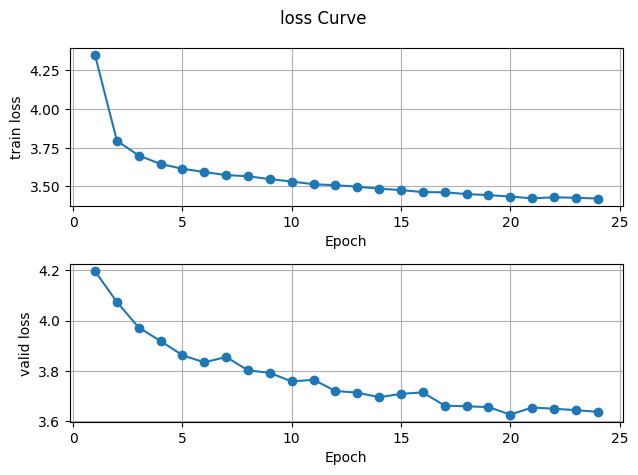

In [40]:
# 결과 시각화

plot_loss_curve(loss_history, metric="loss", overlap=False)

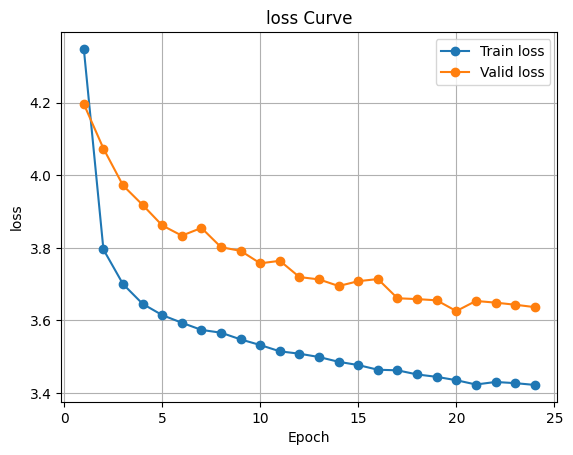

In [41]:
plot_loss_curve(loss_history, metric="loss", overlap=True)

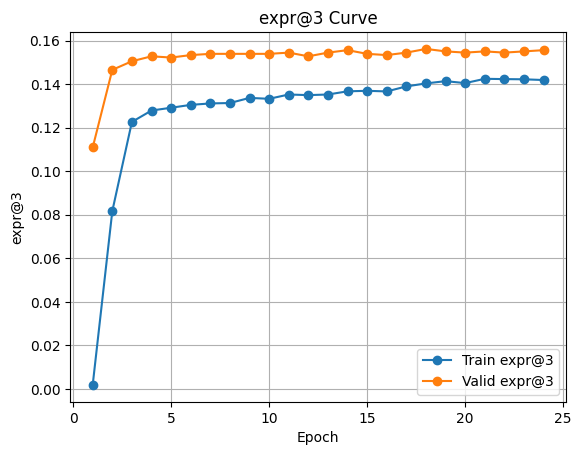

In [42]:
plot_loss_curve(loss_history, metric="expr@3", overlap=True)

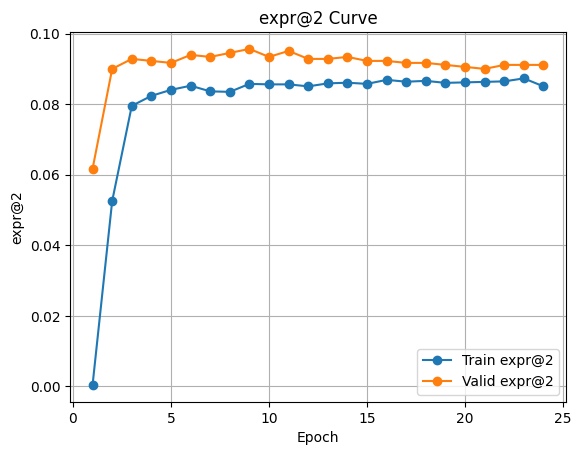

In [43]:
plot_loss_curve(loss_history, metric="expr@2", overlap=True)

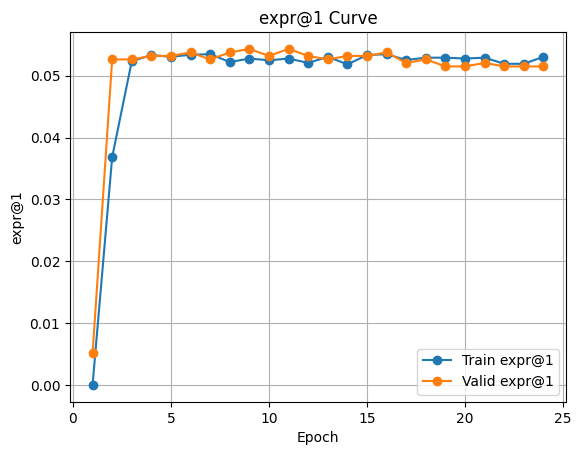

In [44]:
plot_loss_curve(loss_history, metric="expr@1", overlap=True)

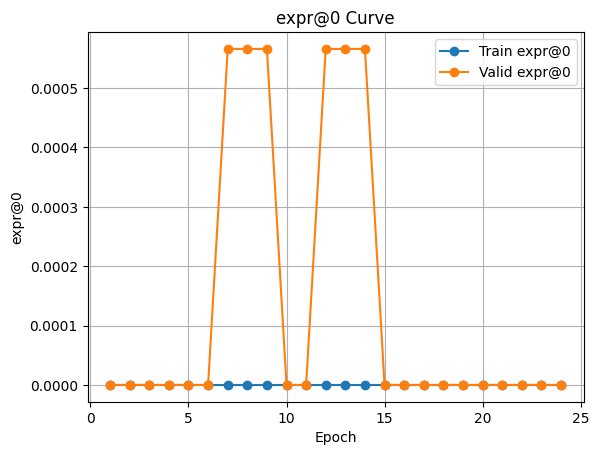

In [45]:
plot_loss_curve(loss_history, metric="expr@0", overlap=True)

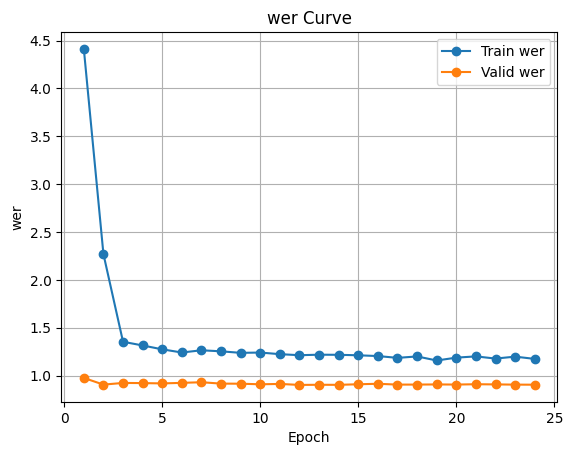

In [46]:
plot_loss_curve(loss_history, metric="wer", overlap=True)

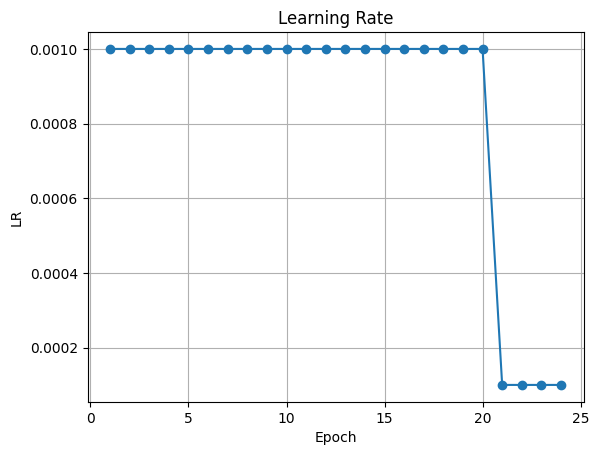

In [47]:
train = loss_history["Train"]

epochs = []
lr = []
for i, history in enumerate(train):
    lr_list = history["lr"]
    epochs.append(i+1)
    lr.append(lr_list[0])

plt.plot(epochs, lr, marker='o')
plt.xlabel("Epoch")
plt.ylabel("LR")
plt.grid(True)
plt.title("Learning Rate")
plt.show()

# Test
- todo: 지금 저장하는 expr은 배치별 평균값이므로 실제 논문에서 언급되는, 다른 모델과 비교하기 위한 expr 척도로는 활용 불가능함 -> 평균 expr이 아니라, 전체 테스트 데이터에 대한 exact match를 count해서 데이터셋 크기로 나눠서 비교할 수 있게 수정해야함

In [48]:
criterion = nn.CrossEntropyLoss(ignore_index=CFG["pad_idx"])

def test(enc, dec, test_loader, criterion, device="cuda"):

    eos_idx = CFG["eos_idx"]
    enc.eval()
    dec.eval()

    total_loss = 0.0
    total_expr_0, total_expr_1, total_expr_2, total_expr_3 = 0.0, 0.0, 0.0, 0.0
    total_wer = 0.0
    num_batches = 0

    loop = tqdm(test_loader, leave=True)

    for i, batch in enumerate(loop):
        loop.set_description(f"[Test] batch:{i}/{len(test_loader)}")

        imgs = batch["image"].to(device)
        labels = batch["formula"].to(device)

        curr_batch_size = imgs.shape[0]
        T = labels.shape[1]

        enc_low_res, enc_high_res = enc(imgs)
        dec.reset(curr_batch_size)
        hidden = dec.init_hidden(curr_batch_size).to(device)

        # starts with a SOS token
        sequence = torch.full(
            (curr_batch_size, 1),
            0,   # <sos> 토큰
            dtype=torch.long,
            device=device
        )

        length = get_lengths(labels, eos_id=CFG["eos_idx"])   # (B,)

        decoded_values = []
        finished = torch.zeros(curr_batch_size, dtype=torch.bool, device=device)  # EOS 도달여부 체크

        for i in range(T-1):
            previous = sequence[:, -1]
            previous = previous.view(-1,1)
            out, hidden = dec(previous, hidden, enc_low_res, enc_high_res)
            hidden = hidden.detach()
            _, top1_id = torch.topk(out, 1)

            # EOS 여부 체크 (eos 이후 부분은 어차피 ignore_idx에 의해 무시되므로 굳이 vocab에 없는 pad로 채우지 않고 그대로 둠)
            is_eos_step = (i == length-1)

            # 이미 EOS가 나온 샘플은 이전 EOS를 그대로 유지 (업데이트 안함)
            top1_id[finished.unsqueeze(1)] = CFG["eos_idx"]

            finished = finished | is_eos_step

            sequence = torch.cat((sequence, top1_id), dim=1)
            decoded_values.append(out)

            if finished.all():
                break

        pred = torch.stack(decoded_values, dim=2).to(device)  # 이때 pred는 sos 토큰을 포함하지 않음 (B,V,T-1)
        labels = labels[:, 1:]                  # sos부분은 제외: (B,T) => (B,T-1)

        loss = criterion(pred.transpose(1,2), labels)  # nn.CrossEntropyLoss() input shape 규칙에 따라 (B,V,T-1)로 pred가 와야하므로 맞춰줌
        pred_tokens = pred.argmax(dim=-1)       # (B,T-1,V) -> (B,T-1)

        expr_0 = float(exprate_k(preds=pred_tokens, targets=labels, k=0, eos_idx=eos_idx))
        expr_1 = float(exprate_k(preds=pred_tokens, targets=labels, k=1, eos_idx=eos_idx))
        expr_2 = float(exprate_k(preds=pred_tokens, targets=labels, k=2, eos_idx=eos_idx))
        expr_3 = float(exprate_k(preds=pred_tokens, targets=labels, k=3, eos_idx=eos_idx))
        wer = float(WER(preds=pred_tokens, targets=labels, eos_idx=eos_idx))

        total_loss += float(loss.item())
        total_expr_0 += expr_0
        total_expr_1 += expr_1
        total_expr_2 += expr_2
        total_expr_3 += expr_3
        total_wer += wer
        num_batches += 1

        loop.set_postfix(loss=loss.item(), expr0=expr_0, expr1=expr_1, expr2=expr_2, expr3=expr_3, wer=wer)

    avg_loss = total_loss / num_batches
    avg_expr_0 = total_expr_0 / num_batches
    avg_expr_1 = total_expr_1 / num_batches
    avg_expr_2 = total_expr_2 / num_batches
    avg_expr_3 = total_expr_3 / num_batches
    avg_wer = total_wer / num_batches

    return avg_loss, avg_expr_0, avg_expr_1, avg_expr_2, avg_expr_3, avg_wer

In [49]:
# best_model.pth 가져오기

enc = Encoder().to(DEVICE)
enc.load_state_dict(torch.load(CFG["paths"]["best_ckpt"])["encoder"])

dec = Decoder(
        num_classes=112,
        low_res_shape=(684,8,48),
        high_res_shape=(792,16,96),
        hidden_size=256,
        embedding_dim=256,
        checkpoint=None,
        device=DEVICE
    ).to(DEVICE)

dec.load_state_dict(torch.load(CFG["paths"]["best_ckpt"])["decoder"])

<All keys matched successfully>

In [50]:
# 테스트 및 테스트 결과 구글스프레드시트에 저장

from tqdm import tqdm

test_loaders = [crohme_testloader_2014, crohme_testloader_2016, crohme_testloader_2019,
                cropme_testloader_2014, cropme_testloader_2016, cropme_testloader_2019,
                im2latex_hme_testloader, im2latex_pme_testloader]

test_dataset_names = ["CROHME_2014", "CROHME_2016", "CROHME_2019", "CROPME_2014", "CROPME_2016", "CROPME_2019", "IM2LATEX_HME", "IM2LATEX_PME"]

val_dict = {"loss": [],
            "expr@0": [],
            "expr@1": [],
            "expr@2": [],
            "expr@3": [],
            "wer": []}

for i, test_loader in enumerate(test_loaders):
    test_dataset_name = test_dataset_names[i]
    print(test_dataset_name)

    loss, expr0, expr1, expr2, expr3, wer = test(enc, dec, test_loader, criterion)
    val_dict["loss"].append(loss)
    val_dict["expr@0"].append(expr0)
    val_dict["expr@1"].append(expr1)
    val_dict["expr@2"].append(expr2)
    val_dict["expr@3"].append(expr3)
    val_dict["wer"].append(wer)


save_test_result(CFG["experiment_name"], val_dict)

CROHME_2014


[Test] batch:0/986:   0%|          | 0/986 [00:00<?, ?it/s]


RuntimeError: Expected target size [1, 112], got [1, 3]

# Prediction 샘플 시각화

In [ ]:
import numpy as np

batch = next(iter(trainloader))
imgs = batch['image'].to(DEVICE)
labels = batch['formula'].to(DEVICE)

curr_batch_size = imgs.shape[0]
T = labels.shape[1]

enc_low_res, enc_high_res = enc(imgs)
dec.reset(curr_batch_size)
hidden = dec.init_hidden(curr_batch_size).to(device)

# starts with a SOS token
sequence = torch.full(
    (curr_batch_size, 1),
    0,   # <sos> 토큰
    dtype=torch.long,
    device=device
)


decoded_values = []
finished = torch.zeros(curr_batch_size, dtype=torch.bool, device=device)  # EOS 도달여부 체크

length = get_lengths(labels, eos_id=CFG["eos_idx"])   # (B,)

for i in range(T-1):
    previous = sequence[:, -1]
    previous = previous.view(-1,1)
    out, hidden = dec(previous, hidden, enc_low_res, enc_high_res)
    hidden = hidden.detach()
    _, top1_id = torch.topk(out, 1)

    # 아직 EOS 안나온 샘플만 업데이트 (finished 부분은 pad처리)
    is_eos_step = (i == length-1)
    finished = finished | is_eos_step

    sequence = torch.cat((sequence, top1_id), dim=1)
    decoded_values.append(out)

    if finished.all():
        break

pred = torch.stack(decoded_values, dim=2).to(device)  # 이때 pred는 sos 토큰을 포함하지 않음
labels = labels[:, 1:]                  # sos부분은 제외: (B,T) => (B,T-1)

loss = criterion(pred, labels)  # nn.CrossEntropyLoss() input shape 규칙에 따라 (B,V,T-1)로 pred가 와야하므로 맞춰줌
pred_tokens = pred.argmax(dim=1)       # (B,V,T-1) -> (B,T-1)

y_hats = pred_tokens

plot_dataset(images, labels, grid_width=1, grid_height=1, figure_width=1, figure_height=1, y_hats=y_hats, vocab=vocab)

In [ ]:
import numpy as np

batch = next(iter(crohme_testloader_2014))
imgs = batch['image'].to(DEVICE)
labels = batch['formula'].to(DEVICE)

curr_batch_size = imgs.shape[0]
T = labels.shape[1]

enc_low_res, enc_high_res = enc(imgs)
dec.reset(curr_batch_size)
hidden = dec.init_hidden(curr_batch_size).to(device)

# starts with a SOS token
sequence = torch.full(
    (curr_batch_size, 1),
    0,   # <sos> 토큰
    dtype=torch.long,
    device=device
)


decoded_values = []
finished = torch.zeros(curr_batch_size, dtype=torch.bool, device=device)  # EOS 도달여부 체크

length = get_lengths(labels, eos_id=CFG["eos_idx"])   # (B,)

for i in range(T-1):
    previous = sequence[:, -1]
    previous = previous.view(-1,1)
    out, hidden = dec(previous, hidden, enc_low_res, enc_high_res)
    hidden = hidden.detach()
    _, top1_id = torch.topk(out, 1)

    # 아직 EOS 안나온 샘플만 업데이트 (finished 부분은 pad처리)
    is_eos_step = (i == length-1)
    finished = finished | is_eos_step

    sequence = torch.cat((sequence, top1_id), dim=1)
    decoded_values.append(out)

    if finished.all():
        break

pred = torch.stack(decoded_values, dim=2).to(device)  # 이때 pred는 sos 토큰을 포함하지 않음
labels = labels[:, 1:]                  # sos부분은 제외: (B,T) => (B,T-1)

loss = criterion(pred, labels)  # nn.CrossEntropyLoss() input shape 규칙에 따라 (B,V,T-1)로 pred가 와야하므로 맞춰줌
pred_tokens = pred.argmax(dim=1)       # (B,V,T-1) -> (B,T-1)

y_hats = pred_tokens

plot_dataset(images, labels, grid_width=1, grid_height=1, figure_width=1, figure_height=1, y_hats=y_hats, vocab=vocab)

In [ ]:
import numpy as np

batch = next(iter(crohme_testloader_2016))
imgs = batch['image'].to(DEVICE)
labels = batch['formula'].to(DEVICE)

curr_batch_size = imgs.shape[0]
T = labels.shape[1]

enc_low_res, enc_high_res = enc(imgs)
dec.reset(curr_batch_size)
hidden = dec.init_hidden(curr_batch_size).to(device)

# starts with a SOS token
sequence = torch.full(
    (curr_batch_size, 1),
    0,   # <sos> 토큰
    dtype=torch.long,
    device=device
)


decoded_values = []
finished = torch.zeros(curr_batch_size, dtype=torch.bool, device=device)  # EOS 도달여부 체크

length = get_lengths(labels, eos_id=CFG["eos_idx"])   # (B,)

for i in range(T-1):
    previous = sequence[:, -1]
    previous = previous.view(-1,1)
    out, hidden = dec(previous, hidden, enc_low_res, enc_high_res)
    hidden = hidden.detach()
    _, top1_id = torch.topk(out, 1)

    # 아직 EOS 안나온 샘플만 업데이트 (finished 부분은 pad처리)
    is_eos_step = (i == length-1)
    finished = finished | is_eos_step

    sequence = torch.cat((sequence, top1_id), dim=1)
    decoded_values.append(out)

    if finished.all():
        break

pred = torch.stack(decoded_values, dim=2).to(device)  # 이때 pred는 sos 토큰을 포함하지 않음
labels = labels[:, 1:]                  # sos부분은 제외: (B,T) => (B,T-1)

loss = criterion(pred, labels)  # nn.CrossEntropyLoss() input shape 규칙에 따라 (B,V,T-1)로 pred가 와야하므로 맞춰줌
pred_tokens = pred.argmax(dim=1)       # (B,V,T-1) -> (B,T-1)

y_hats = pred_tokens

plot_dataset(images, labels, grid_width=1, grid_height=1, figure_width=1, figure_height=1, y_hats=y_hats, vocab=vocab)

In [ ]:
import numpy as np

batch = next(iter(crohme_testloader_2019))
imgs = batch['image'].to(DEVICE)
labels = batch['formula'].to(DEVICE)

curr_batch_size = imgs.shape[0]
T = labels.shape[1]

enc_low_res, enc_high_res = enc(imgs)
dec.reset(curr_batch_size)
hidden = dec.init_hidden(curr_batch_size).to(device)

# starts with a SOS token
sequence = torch.full(
    (curr_batch_size, 1),
    0,   # <sos> 토큰
    dtype=torch.long,
    device=device
)


decoded_values = []
finished = torch.zeros(curr_batch_size, dtype=torch.bool, device=device)  # EOS 도달여부 체크

length = get_lengths(labels, eos_id=CFG["eos_idx"])   # (B,)

for i in range(T-1):
    previous = sequence[:, -1]
    previous = previous.view(-1,1)
    out, hidden = dec(previous, hidden, enc_low_res, enc_high_res)
    hidden = hidden.detach()
    _, top1_id = torch.topk(out, 1)

    # 아직 EOS 안나온 샘플만 업데이트 (finished 부분은 pad처리)
    is_eos_step = (i == length-1)
    finished = finished | is_eos_step

    sequence = torch.cat((sequence, top1_id), dim=1)
    decoded_values.append(out)

    if finished.all():
        break

pred = torch.stack(decoded_values, dim=2).to(device)  # 이때 pred는 sos 토큰을 포함하지 않음
labels = labels[:, 1:]                  # sos부분은 제외: (B,T) => (B,T-1)

loss = criterion(pred, labels)  # nn.CrossEntropyLoss() input shape 규칙에 따라 (B,V,T-1)로 pred가 와야하므로 맞춰줌
pred_tokens = pred.argmax(dim=1)       # (B,V,T-1) -> (B,T-1)

y_hats = pred_tokens

plot_dataset(images, labels, grid_width=1, grid_height=1, figure_width=1, figure_height=1, y_hats=y_hats, vocab=vocab)

In [ ]:
import numpy as np

batch = next(iter(cropme_testloader_2014))
imgs = batch['image'].to(DEVICE)
labels = batch['formula'].to(DEVICE)

curr_batch_size = imgs.shape[0]
T = labels.shape[1]

enc_low_res, enc_high_res = enc(imgs)
dec.reset(curr_batch_size)
hidden = dec.init_hidden(curr_batch_size).to(device)

# starts with a SOS token
sequence = torch.full(
    (curr_batch_size, 1),
    0,   # <sos> 토큰
    dtype=torch.long,
    device=device
)


decoded_values = []
finished = torch.zeros(curr_batch_size, dtype=torch.bool, device=device)  # EOS 도달여부 체크

length = get_lengths(labels, eos_id=CFG["eos_idx"])   # (B,)

for i in range(T-1):
    previous = sequence[:, -1]
    previous = previous.view(-1,1)
    out, hidden = dec(previous, hidden, enc_low_res, enc_high_res)
    hidden = hidden.detach()
    _, top1_id = torch.topk(out, 1)

    # 아직 EOS 안나온 샘플만 업데이트 (finished 부분은 pad처리)
    is_eos_step = (i == length-1)
    finished = finished | is_eos_step

    sequence = torch.cat((sequence, top1_id), dim=1)
    decoded_values.append(out)

    if finished.all():
        break

pred = torch.stack(decoded_values, dim=2).to(device)  # 이때 pred는 sos 토큰을 포함하지 않음
labels = labels[:, 1:]                  # sos부분은 제외: (B,T) => (B,T-1)

loss = criterion(pred, labels)  # nn.CrossEntropyLoss() input shape 규칙에 따라 (B,V,T-1)로 pred가 와야하므로 맞춰줌
pred_tokens = pred.argmax(dim=1)       # (B,V,T-1) -> (B,T-1)

y_hats = pred_tokens

plot_dataset(images, labels, grid_width=1, grid_height=1, figure_width=1, figure_height=1, y_hats=y_hats, vocab=vocab)

In [ ]:
import numpy as np

batch = next(iter(cropme_testloader_2016))
imgs = batch['image'].to(DEVICE)
labels = batch['formula'].to(DEVICE)

curr_batch_size = imgs.shape[0]
T = labels.shape[1]

enc_low_res, enc_high_res = enc(imgs)
dec.reset(curr_batch_size)
hidden = dec.init_hidden(curr_batch_size).to(device)

# starts with a SOS token
sequence = torch.full(
    (curr_batch_size, 1),
    0,   # <sos> 토큰
    dtype=torch.long,
    device=device
)


decoded_values = []
finished = torch.zeros(curr_batch_size, dtype=torch.bool, device=device)  # EOS 도달여부 체크

length = get_lengths(labels, eos_id=CFG["eos_idx"])   # (B,)

for i in range(T-1):
    previous = sequence[:, -1]
    previous = previous.view(-1,1)
    out, hidden = dec(previous, hidden, enc_low_res, enc_high_res)
    hidden = hidden.detach()
    _, top1_id = torch.topk(out, 1)

    # 아직 EOS 안나온 샘플만 업데이트 (finished 부분은 pad처리)
    is_eos_step = (i == length-1)
    finished = finished | is_eos_step

    sequence = torch.cat((sequence, top1_id), dim=1)
    decoded_values.append(out)

    if finished.all():
        break

pred = torch.stack(decoded_values, dim=2).to(device)  # 이때 pred는 sos 토큰을 포함하지 않음
labels = labels[:, 1:]                  # sos부분은 제외: (B,T) => (B,T-1)

loss = criterion(pred, labels)  # nn.CrossEntropyLoss() input shape 규칙에 따라 (B,V,T-1)로 pred가 와야하므로 맞춰줌
pred_tokens = pred.argmax(dim=1)       # (B,V,T-1) -> (B,T-1)

y_hats = pred_tokens

plot_dataset(images, labels, grid_width=1, grid_height=1, figure_width=1, figure_height=1, y_hats=y_hats, vocab=vocab)

In [ ]:
import numpy as np

batch = next(iter(cropme_testloader_2019))
imgs = batch['image'].to(DEVICE)
labels = batch['formula'].to(DEVICE)

curr_batch_size = imgs.shape[0]
T = labels.shape[1]

enc_low_res, enc_high_res = enc(imgs)
dec.reset(curr_batch_size)
hidden = dec.init_hidden(curr_batch_size).to(device)

# starts with a SOS token
sequence = torch.full(
    (curr_batch_size, 1),
    0,   # <sos> 토큰
    dtype=torch.long,
    device=device
)


decoded_values = []
finished = torch.zeros(curr_batch_size, dtype=torch.bool, device=device)  # EOS 도달여부 체크

length = get_lengths(labels, eos_id=CFG["eos_idx"])   # (B,)

for i in range(T-1):
    previous = sequence[:, -1]
    previous = previous.view(-1,1)
    out, hidden = dec(previous, hidden, enc_low_res, enc_high_res)
    hidden = hidden.detach()
    _, top1_id = torch.topk(out, 1)

    # 아직 EOS 안나온 샘플만 업데이트 (finished 부분은 pad처리)
    is_eos_step = (i == length-1)
    finished = finished | is_eos_step

    sequence = torch.cat((sequence, top1_id), dim=1)
    decoded_values.append(out)

    if finished.all():
        break

pred = torch.stack(decoded_values, dim=2).to(device)  # 이때 pred는 sos 토큰을 포함하지 않음
labels = labels[:, 1:]                  # sos부분은 제외: (B,T) => (B,T-1)

loss = criterion(pred, labels)  # nn.CrossEntropyLoss() input shape 규칙에 따라 (B,V,T-1)로 pred가 와야하므로 맞춰줌
pred_tokens = pred.argmax(dim=1)       # (B,V,T-1) -> (B,T-1)

y_hats = pred_tokens

plot_dataset(images, labels, grid_width=1, grid_height=1, figure_width=1, figure_height=1, y_hats=y_hats, vocab=vocab)

In [ ]:
import numpy as np

batch = next(iter(im2latex_hme_testloader))
imgs = batch['image'].to(DEVICE)
labels = batch['formula'].to(DEVICE)

curr_batch_size = imgs.shape[0]
T = labels.shape[1]

enc_low_res, enc_high_res = enc(imgs)
dec.reset(curr_batch_size)
hidden = dec.init_hidden(curr_batch_size).to(device)

# starts with a SOS token
sequence = torch.full(
    (curr_batch_size, 1),
    0,   # <sos> 토큰
    dtype=torch.long,
    device=device
)


decoded_values = []
finished = torch.zeros(curr_batch_size, dtype=torch.bool, device=device)  # EOS 도달여부 체크

length = get_lengths(labels, eos_id=CFG["eos_idx"])   # (B,)

for i in range(T-1):
    previous = sequence[:, -1]
    previous = previous.view(-1,1)
    out, hidden = dec(previous, hidden, enc_low_res, enc_high_res)
    hidden = hidden.detach()
    _, top1_id = torch.topk(out, 1)

    # 아직 EOS 안나온 샘플만 업데이트 (finished 부분은 pad처리)
    is_eos_step = (i == length-1)
    finished = finished | is_eos_step

    sequence = torch.cat((sequence, top1_id), dim=1)
    decoded_values.append(out)

    if finished.all():
        break

pred = torch.stack(decoded_values, dim=2).to(device)  # 이때 pred는 sos 토큰을 포함하지 않음
labels = labels[:, 1:]                  # sos부분은 제외: (B,T) => (B,T-1)

loss = criterion(pred, labels)  # nn.CrossEntropyLoss() input shape 규칙에 따라 (B,V,T-1)로 pred가 와야하므로 맞춰줌
pred_tokens = pred.argmax(dim=1)       # (B,V,T-1) -> (B,T-1)

y_hats = pred_tokens

plot_dataset(images, labels, grid_width=1, grid_height=1, figure_width=1, figure_height=1, y_hats=y_hats, vocab=vocab)

In [ ]:
import numpy as np

batch = next(iter(im2latex_pme_testloader))
imgs = batch['image'].to(DEVICE)
labels = batch['formula'].to(DEVICE)

curr_batch_size = imgs.shape[0]
T = labels.shape[1]

enc_low_res, enc_high_res = enc(imgs)
dec.reset(curr_batch_size)
hidden = dec.init_hidden(curr_batch_size).to(device)

# starts with a SOS token
sequence = torch.full(
    (curr_batch_size, 1),
    0,   # <sos> 토큰
    dtype=torch.long,
    device=device
)


decoded_values = []
finished = torch.zeros(curr_batch_size, dtype=torch.bool, device=device)  # EOS 도달여부 체크

length = get_lengths(labels, eos_id=CFG["eos_idx"])   # (B,)

for i in range(T-1):
    previous = sequence[:, -1]
    previous = previous.view(-1,1)
    out, hidden = dec(previous, hidden, enc_low_res, enc_high_res)
    hidden = hidden.detach()
    _, top1_id = torch.topk(out, 1)

    # 아직 EOS 안나온 샘플만 업데이트 (finished 부분은 pad처리)
    is_eos_step = (i == length-1)
    finished = finished | is_eos_step

    sequence = torch.cat((sequence, top1_id), dim=1)
    decoded_values.append(out)

    if finished.all():
        break

pred = torch.stack(decoded_values, dim=2).to(device)  # 이때 pred는 sos 토큰을 포함하지 않음
labels = labels[:, 1:]                  # sos부분은 제외: (B,T) => (B,T-1)

loss = criterion(pred, labels)  # nn.CrossEntropyLoss() input shape 규칙에 따라 (B,V,T-1)로 pred가 와야하므로 맞춰줌
pred_tokens = pred.argmax(dim=1)       # (B,V,T-1) -> (B,T-1)

y_hats = pred_tokens

plot_dataset(images, labels, grid_width=1, grid_height=1, figure_width=1, figure_height=1, y_hats=y_hats, vocab=vocab)

## 디버깅

- exprate 계산 시, 단순히 @k로 해버리면 우연히 토큰길이가 k보다 작으면 아예 예측을 이상하게 해도 맞다고 처리해버리는 문제 발견 => 이 부분 개선하도록 메트릭 수정 및 캐글이나 네이버부스트코스  자료 등 코드에는 이 부분 처리하도록 되어있는지 확인할 것
- 논문에서처럼 학습의 어떤 부분이 이미지의 어떤 부분을 참고하고 있는지 시각화해서 xAI방법에서 디버깅해보기 -> 잘 학습되고 있는지,,, (WAP 논문 시각화를 직접 해보는 느낌)
- 128*768로 resize해서 시작 안하고 128x128에서부터 시작해보기? (지푸라기라도 잡는 심정)
- 어떻게 추가할지는 모르겠지만,정칙화 텀을 추가해보기?
- 그래도 안되면 기본 방법은 어느정도 예측 잘할때까지 학습하려면 기본적으로 에포크 너무많이 필요해서 그런거라고 생각하고 트랜스포머 기반으로 바로 적용 시도하는걸로 넘어가기, 트랜스포머 기반으로 두 도메인 이용할 수 있도록 고민해보기)
- dla나 wap에서 어텐션 이외에 추가적으로 도입했던, 내가 구현할때 미처 반영하지 못한 부분 있으면 반영해서 다시 수정해보기

# Next Step
- 멀티헤드셀프어텐션 이용해서 MSA라고 실험제목 붙였는데, Multi Scale Attnetion과 혼동되지 않도록 실험 폴더 및 스프레드시트 셀 이름 바꿔야할듯 <br><br>
- 공유 폴더 계정말고 다른 구글계정으로 돌렸으므로 처음 chdir 경로 바꾸고 깃허브에 올릴 것 / 혹은 바로가기 경로 추가해서 공유폴더 계정 위치에 실험결과 저장해도록 만들어두기<br><br>

- DLA_single 노트북의 validation, test 함수 부분 model.inference로 y_hat 구하는 걸로 수정
- rendered images도 들어오는 경우 처리하는 코드 작성
- dla_single 구혀에서 바다나우 어텐션 적용 시 쿼리를 디코더 인풋으로 삼았던 것 같은데, hidden state라고 생각해서 수정해보기 + coverage attention 철학도 반영해서 수정해보기?
- cosineAnnealingWarmup 의 첫 warmup 단계를 조금 덜 급하게 수정? (ex 0.1 -> 0.01, 주기를 줄이거나 늘리기, 주기 돌때마다 학습률 값을 특정 비율로 감소시키는 등)
- 지금 hme, pme pair가 반드시 각 이미지 패치가 와넌 서로 동일한 부분 나타내는거 아닌데도 mse로 비교하는게 좋은 접근법일까? receptive field가 확장되어있기에 괜찮다고 보는건가?

<br><br>
- Densenet 내부 구현 디테일 공부해보기 -> WAP, DLA, PAL논문 읽으며 인코더 디테일 구조 다시한번 체크해보기
- beamsearch, top-k, top-p 등 다른 디코딩 (inference) 방법 적용
- 현재 service account api 토큰 때문에 github private로 해둠 -> service account api를 env등으로 암호화 및 gitignore에 추가한 후 public으로 github 폴더 visibility 변경해두기

<br><br>
- 옵션
    - 바다나우 어텐션 대신 루옹 어텐션 적용 (소연 코드 참고)
